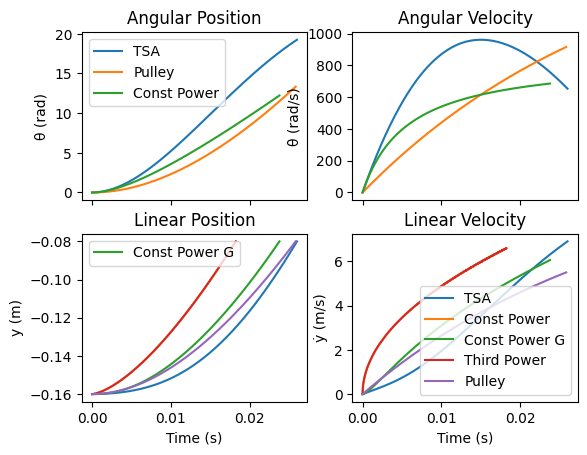

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

DT = 0.00001

tau_max = 0.2795 #Nm
w_max = 1704 #rad/s
m = 0.100 #kg
I = 0.5 * (37.4/1000/2) * (28.4/1000/2)**2 #kg m^2
# g = 9.81 #m/s^2
g = 0 #m/s^2

def num_integration(y0, stroke, CVT_G_dG_dt):

    def dynamics(t, states):
        y = states[0] # output linear position (always positive, string base is 0)
        yd = states[1] # output linear velocity (negative)

        G, dG_dt = CVT_G_dG_dt(t, y, yd)
        
        ydd = (G * tau_max*(1 - G*yd/w_max) + m*g - (I * G * dG_dt * yd)) / (m + I*G**2)
        return [yd, ydd]

    def stroke_end_event(t, x):
        y, yd = x
        return y - (y0 - stroke)
    stroke_end_event.terminal = True
    stroke_end_event.direction = -1 #triggers if went from postive to negative
    
    initial_state = [y0-1e-6, 0]
    end_time = 2
    t_eval = np.arange(0, end_time, DT)

    sol = solve_ivp(dynamics, [0, end_time], initial_state, events=stroke_end_event, t_eval=t_eval, method='RK45', vectorized=False)
    t_num = sol.t
    y_num = sol.y[0]
    yd_num = sol.y[1]
    G, dG_dt = CVT_G_dG_dt(t_num, y_num, yd_num)
    thetad_num = yd_num*G
    theta_num = np.cumsum(thetad_num*DT)

    return t_num, theta_num, thetad_num, y_num, yd_num


def TSA_G_dG_dt(t, y, yd):
    L = 0.162
    r = 0.006
    sqrt_term = np.sqrt(L**2 - y**2)
    G = -y / (r * sqrt_term)
    dG_dt = - (L**2) / (r * (sqrt_term**3)) * yd
    return G, dG_dt

def Pulley_G_dG_dt(t, y, yd):
    r = 0.006
    G = -1/r
    dG_dt = 0
    return G, dG_dt

def const_power_G_dG_dt(t, y, yd):
    P_max = tau_max*w_max/4
    t = t + 1e-10
    F = (P_max*m)/(2*t)
    
    G = np.sqrt(m*w_max/(2*tau_max*t))
    # G = F/(tau_max/2)
    dG_dt = -w_max*m/(2**(3/2)*tau_max*np.sqrt(w_max*m/(tau_max*t))*t**2)
    return -G, -dG_dt

def num_integration_const_power(y0, stroke):
    def dynamics(t, states):
        y, yd = states
        P_max = tau_max*w_max/4
        yd_desired = -np.sqrt(2*P_max/m * t)
        ydd = 100000*(yd_desired - yd)
        return [yd, ydd]
    
    def stroke_end_event(t, x):
        y, yd = x
        return y - (y0 - stroke)
    stroke_end_event.terminal = True
    stroke_end_event.direction = -1 #triggers if went from postive to negative
    
    initial_state = [y0, 0]
    end_time = 2
    t_eval = np.arange(0, end_time, DT)

    sol = solve_ivp(dynamics, [0, end_time], initial_state, events=stroke_end_event, t_eval=t_eval, method='RK45', vectorized=False)
    t_num = sol.t
    y_num = sol.y[0]
    yd_num = sol.y[1]
    theta_num = np.cumsum(y_num*DT)
    thetad_num = yd_num
    return t_num, theta_num, thetad_num, y_num, yd_num

def num_integration_third(y0, stroke):
    def dynamics(t, states):
        y, yd = states
        P_max = tau_max*w_max/4
        yd_desired = -np.pow(3*P_max*(y0-y)/m, 1/3)
        ydd = 1000000*(yd_desired - yd)
        return [yd, ydd]
    
    def stroke_end_event(t, x):
        y, yd = x
        return y - (y0 - stroke)
    stroke_end_event.terminal = True
    stroke_end_event.direction = -1 #triggers if went from postive to negative
    
    initial_state = [y0-1e-6, 0]
    end_time = 2
    t_eval = np.arange(0, end_time, DT)

    sol = solve_ivp(dynamics, [0, end_time], initial_state, events=stroke_end_event, t_eval=t_eval, method='RK45', vectorized=False)
    t_num = sol.t
    y_num = sol.y[0]
    yd_num = sol.y[1]
    theta_num = np.cumsum(y_num*DT)
    thetad_num = yd_num
    return t_num, theta_num, thetad_num, y_num, yd_num

stroke = 0.080
y0 = 0.160
t_tsa, theta_tsa, thetad_tsa, y_tsa, yd_tsa = num_integration(y0=y0, stroke=stroke, CVT_G_dG_dt=TSA_G_dG_dt)
t_pulley, theta_pulley, thetad_pulley, y_pulley, yd_pulley = num_integration(y0=y0, stroke=stroke, CVT_G_dG_dt=Pulley_G_dG_dt)
t_const_powerG, theta_const_powerG, thetad_const_powerG, y_const_powerG, yd_const_powerG = num_integration(y0=y0, stroke=stroke, CVT_G_dG_dt=const_power_G_dG_dt)

t_const_power, theta_const_power, thetad_const_power, y_const_power, yd_const_power = num_integration_const_power(y0=y0, stroke=stroke)
t_third, theta_third, thetad_third, y_third, yd_third = num_integration_third(y0=y0, stroke=stroke)

fig, axs = plt.subplots(2, 2, sharex=True)
axs[0,0].plot(t_tsa, theta_tsa, label='TSA')
axs[0,0].plot(t_pulley, theta_pulley, label='Pulley')
axs[0,0].plot(t_const_powerG, theta_const_powerG, label='Const Power')
# axs[0,0].plot(t_const_power, theta_const_power)
axs[0,0].set_ylabel('θ (rad)')
axs[0,0].set_title('Angular Position')
axs[0,0].legend()

axs[0,1].plot(t_tsa, thetad_tsa)
axs[0,1].plot(t_pulley, thetad_pulley)
axs[0,1].plot(t_const_powerG, thetad_const_powerG, label='Const Power G')
# axs[0,1].plot(t_const_power, thetad_const_power)

axs[0,1].set_ylabel('θ̇ (rad/s)')
axs[0,1].set_title('Angular Velocity')

axs[1,0].plot(t_tsa, -y_tsa)
axs[1,0].plot(t_const_power, -y_const_power)
axs[1,0].plot(t_const_powerG, -y_const_powerG, label='Const Power G')
axs[1,0].plot(t_third, -y_third)
axs[1,0].plot(t_pulley, -y_pulley)
axs[1,0].set_ylabel('y (m)')
axs[1,0].set_xlabel('Time (s)')
axs[1,0].set_title('Linear Position')
axs[1,0].legend()

axs[1,1].plot(t_tsa, -yd_tsa, label='TSA')
axs[1,1].plot(t_const_power, -yd_const_power, label='Const Power')
axs[1,1].plot(t_const_powerG, -yd_const_powerG, label='Const Power G')
axs[1,1].plot(t_third, -yd_third, label='Third Power')
axs[1,1].plot(t_pulley, -yd_pulley, label='Pulley')
P_max = tau_max*w_max/4
yd_desired = np.sqrt(2*P_max/m * t_const_power)
# axs[1,1].plot(t_const_power, yd_desired, '--')
axs[1,1].set_ylabel('ẏ (m/s)')
axs[1,1].set_xlabel('Time (s)')
axs[1,1].set_title('Linear Velocity')
axs[1,1].legend()





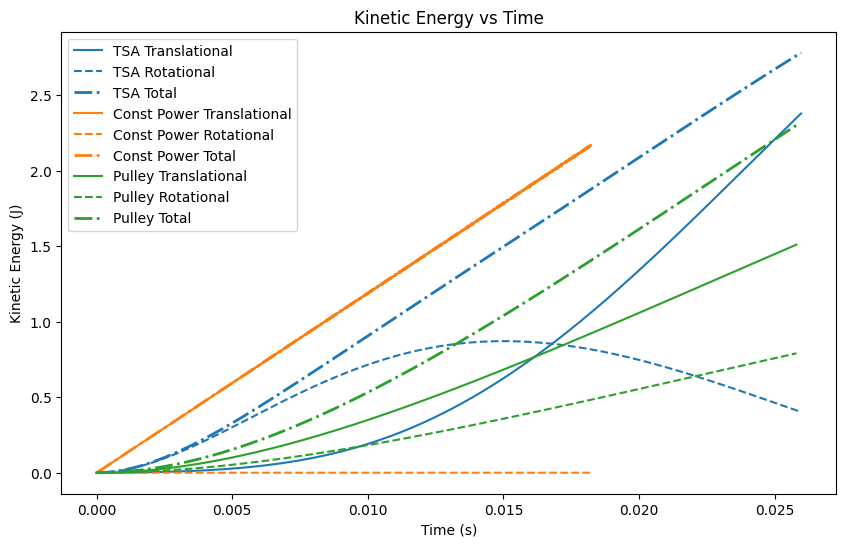

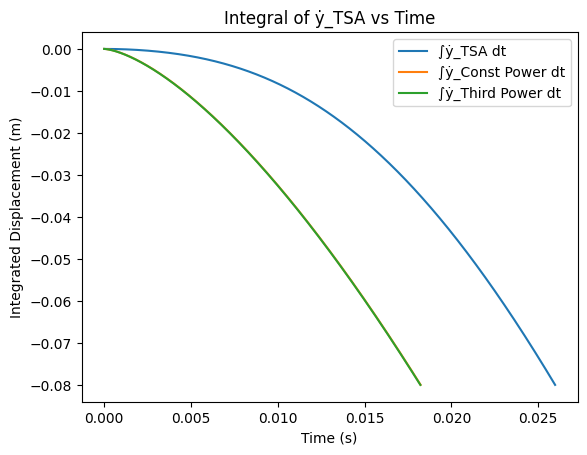

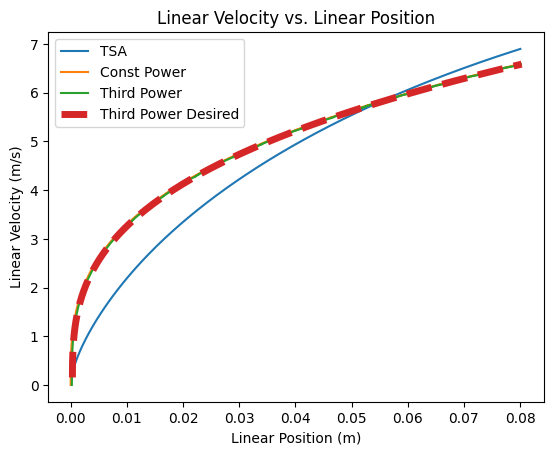

In [104]:

#plot of energy vs time for both 
# Compute total energy (kinetic + potential) for both cases

# For TSA
KE_tsa = 0.5 * m * yd_tsa**2
KE_tsa_rotor = 0.5 * I * thetad_tsa**2

# For Pulley
KE_pulley = 0.5 * m * yd_pulley**2
KE_pulley_rotor = 0.5 * I * thetad_pulley**2

# For constant power
KE_const = 0.5 * m * yd_const_power**2
KE_const_rotor = 0.5 * I * thetad_const_power**2

# For third power
KE_third = 0.5 * m * yd_third**2
KE_third_rotor = 0.5 * I * thetad_third**2

fig_energy, ax_energy = plt.subplots(figsize=(10, 6))
# For TSA, stack translational and rotational KE and plot their sum

# Define consistent colors for TSA and Const Power and Pulley
tsa_color = 'tab:blue'
const_color = 'tab:orange'
pulley_color = 'tab:green'

KE_total_tsa = np.vstack([KE_tsa, KE_tsa_rotor])
ax_energy.plot(t_tsa, KE_total_tsa[0], color=tsa_color, label="TSA Translational")
ax_energy.plot(t_tsa, KE_total_tsa[1], '--', color=tsa_color, label="TSA Rotational")
ax_energy.plot(t_tsa, KE_total_tsa.sum(axis=0), '-.', linewidth=2, color=tsa_color, label="TSA Total")

KE_total_const = np.vstack([KE_const, KE_const_rotor])
ax_energy.plot(t_const_power, KE_total_const[0], color=const_color, label="Const Power Translational")
ax_energy.plot(t_const_power, KE_total_const[1], '--', color=const_color, label="Const Power Rotational")
ax_energy.plot(t_const_power, KE_total_const.sum(axis=0), '-.', linewidth=2, color=const_color, label="Const Power Total")

KE_total_pulley = np.vstack([KE_pulley, KE_pulley_rotor])
ax_energy.plot(t_pulley, KE_total_pulley[0], color=pulley_color, label="Pulley Translational")
ax_energy.plot(t_pulley, KE_total_pulley[1], '--', color=pulley_color, label="Pulley Rotational")
ax_energy.plot(t_pulley, KE_total_pulley.sum(axis=0), '-.', linewidth=2, color=pulley_color, label="Pulley Total")


P_max = tau_max*w_max/4
# ax_energy.plot(t_const_power, P_max*t_const_power, '--', label=f"Power = {P_max:.1f} W")
ax_energy.set_xlabel("Time (s)")
ax_energy.set_ylabel("Kinetic Energy (J)")
ax_energy.set_title("Kinetic Energy vs Time")
ax_energy.legend()
plt.show()


# Compute the integral under the curve of yd_tsa (area under velocity = position difference)
from scipy.integrate import cumulative_trapezoid

# Cumulative integral (to show how position evolves from yd_tsa alone)
position_integral_tsa = cumulative_trapezoid(yd_tsa, t_tsa, initial=0)
position_integral_const_power = cumulative_trapezoid(yd_const_power, t_const_power, initial=0)
position_integral_third = cumulative_trapezoid(yd_third, t_third, initial=0)

fig_integral, ax_integral = plt.subplots()
ax_integral.plot(t_tsa, position_integral_tsa, label="∫ẏ_TSA dt")
ax_integral.plot(t_const_power, position_integral_const_power, label="∫ẏ_Const Power dt")
ax_integral.plot(t_third, position_integral_third, label="∫ẏ_Third Power dt")
ax_integral.set_xlabel("Time (s)")
ax_integral.set_ylabel("Integrated Displacement (m)")
ax_integral.set_title("Integral of ẏ_TSA vs Time")
ax_integral.legend()
plt.show()


# Plot linear velocity vs linear position for each scenario

fig_lv_pos, ax_lv_pos = plt.subplots()
ax_lv_pos.plot(-position_integral_tsa+0.0001, -yd_tsa, label='TSA')
ax_lv_pos.plot(-position_integral_const_power, -yd_const_power, label='Const Power')
ax_lv_pos.plot(-position_integral_third+0.0002, -yd_third, label='Third Power')

third_vel_desired = np.pow(3*P_max*(y0-y_third)/m, 1/3)
ax_lv_pos.plot((y0-y_third)+0.0003, third_vel_desired, '--', linewidth=5, label='Third Power Desired')

ax_lv_pos.set_xlabel('Linear Position (m)')
ax_lv_pos.set_ylabel('Linear Velocity (m/s)')
ax_lv_pos.set_title('Linear Velocity vs. Linear Position')
ax_lv_pos.legend()
plt.show()

=== Parameters ===
m=1.0 kg, Pmax=100.0 W, s=1.0 m

=== Constant-power (optimal under only power cap) ===
T_cp = 0.224070 s
v_end_cp = 6.694330 m/s
max(P_cp) ≈ 141.421356 W (should be ~Pmax)
stroke achieved x(T) ≈ 1.000037 m

=== Linear v(t) with same duration T_cp and same stroke ===
v_end_linear_sameT = 8.925773 m/s
max(P_linear_sameT) = 355.555556 W  <-- compare to Pmax
stroke achieved x(T) ≈ 1.000050 m

=== Linear v(t) that is feasible under power cap (max power hits Pmax) ===
T_lin_opt = 0.341995 s
v_end_lin_opt = 5.848035 m/s
max(P_lin_opt) ≈ 100.000000 W
stroke achieved x(T) ≈ 1.000050 m


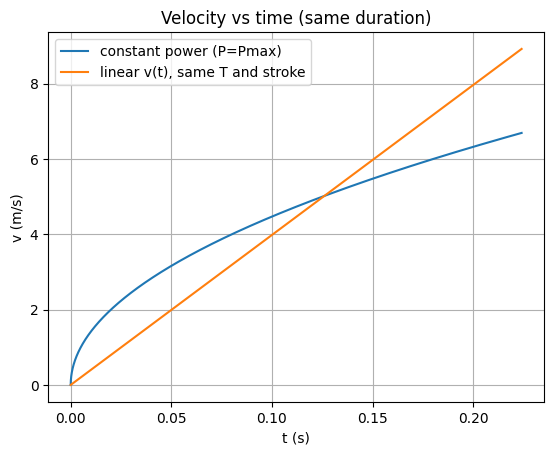

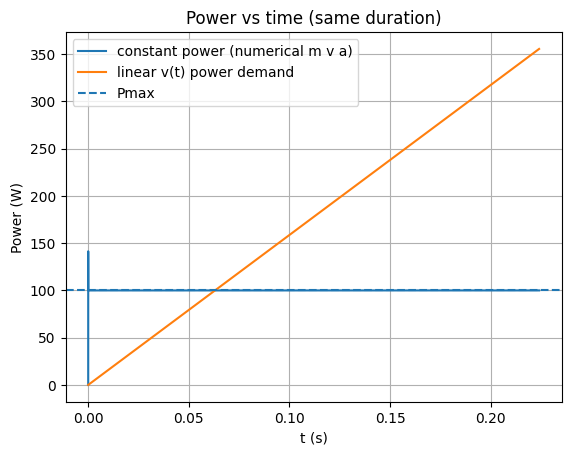

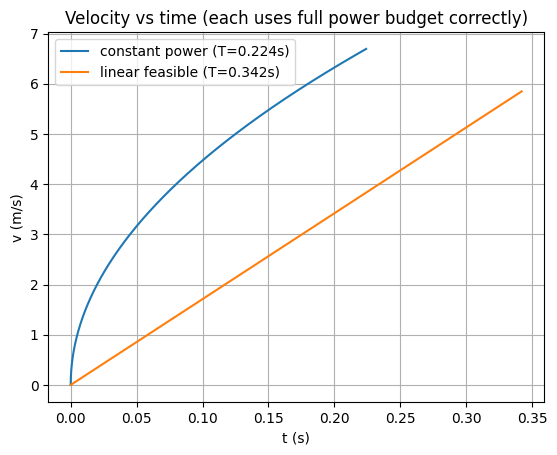

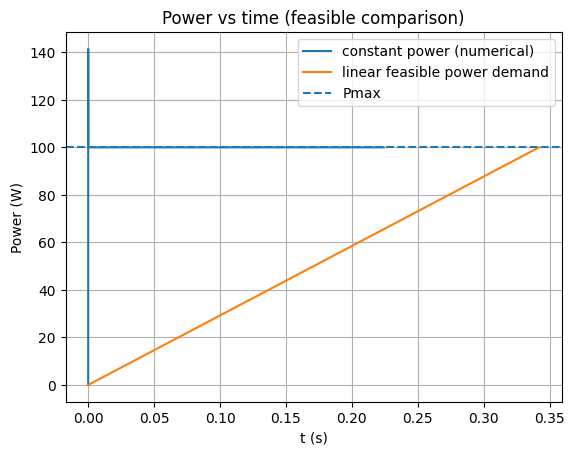

In [89]:
import numpy as np
import matplotlib.pyplot as plt

def const_power_profile(m, Pmax, s, N=20001):
    # v(t) = sqrt(2 P t / m), find T so that integral_0^T v dt = s
    # x(T) = (2/3)*sqrt(2P/m)*T^(3/2)
    T = ((3*s/2) * np.sqrt(m/(2*Pmax)))**(2/3)
    t = np.linspace(0, T, N)
    v = np.sqrt(2*Pmax*t/m)
    # power is constant, but compute from m v dv/dt numerically too
    dt = t[1]-t[0]
    a = np.gradient(v, dt)
    P = m*v*a
    x = np.cumsum(v)*dt
    return t, v, x, P, T

def linear_velocity_profile(m, Pmax, s, T, N=20001):
    # v(t) = (v_end/T) t, with v_end chosen so that integral v dt = s => v_end=2s/T
    t = np.linspace(0, T, N)
    v_end = 2*s/T
    v = v_end*(t/T)
    dt = t[1]-t[0]
    a = np.gradient(v, dt)
    P = m*v*a
    x = np.cumsum(v)*dt
    return t, v, x, P, v_end

def linear_feasible_T_from_power(m, Pmax, s):
    # For v=kt, with stroke constraint -> k=2s/T^2, max power at end: Pmax_lin = 4 m s^2 / T^3
    # Set equal to Pmax to be as aggressive as possible
    T = (4*m*s**2/Pmax)**(1/3)
    v_end = 2*s/T
    return T, v_end

# Example parameters (you can change these)
m = 1.0
Pmax = 100.0
s = 1.0

t_cp, v_cp, x_cp, P_cp, T_cp = const_power_profile(m, Pmax, s)

# Case A: compare against a linear v(t) with the SAME duration T_cp and SAME stroke (area under v)
t_lin_sameT, v_lin_sameT, x_lin_sameT, P_lin_sameT, v_end_sameT = linear_velocity_profile(m, Pmax, s, T_cp)

# Case B: best linear v(t) that respects the power cap (max power hits Pmax at the end)
T_lin_opt, v_end_lin_opt = linear_feasible_T_from_power(m, Pmax, s)
t_lin_opt, v_lin_opt, x_lin_opt, P_lin_opt, _ = linear_velocity_profile(m, Pmax, s, T_lin_opt)

# Print key numbers
v_end_cp = v_cp[-1]
print("=== Parameters ===")
print(f"m={m} kg, Pmax={Pmax} W, s={s} m")
print("\n=== Constant-power (optimal under only power cap) ===")
print(f"T_cp = {T_cp:.6f} s")
print(f"v_end_cp = {v_end_cp:.6f} m/s")
print(f"max(P_cp) ≈ {np.max(P_cp):.6f} W (should be ~Pmax)")
print(f"stroke achieved x(T) ≈ {x_cp[-1]:.6f} m")

print("\n=== Linear v(t) with same duration T_cp and same stroke ===")
print(f"v_end_linear_sameT = {v_end_sameT:.6f} m/s")
print(f"max(P_linear_sameT) = {np.max(P_lin_sameT):.6f} W  <-- compare to Pmax")
print(f"stroke achieved x(T) ≈ {x_lin_sameT[-1]:.6f} m")

print("\n=== Linear v(t) that is feasible under power cap (max power hits Pmax) ===")
print(f"T_lin_opt = {T_lin_opt:.6f} s")
print(f"v_end_lin_opt = {v_end_lin_opt:.6f} m/s")
print(f"max(P_lin_opt) ≈ {np.max(P_lin_opt):.6f} W")
print(f"stroke achieved x(T) ≈ {x_lin_opt[-1]:.6f} m")

# Plot 1: velocity vs time (case with same duration)
plt.figure()
plt.plot(t_cp, v_cp, label="constant power (P=Pmax)")
plt.plot(t_lin_sameT, v_lin_sameT, label="linear v(t), same T and stroke")
plt.xlabel("t (s)")
plt.ylabel("v (m/s)")
plt.title("Velocity vs time (same duration)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: power vs time (case with same duration)
plt.figure()
plt.plot(t_cp, P_cp, label="constant power (numerical m v a)")
plt.plot(t_lin_sameT, P_lin_sameT, label="linear v(t) power demand")
plt.axhline(Pmax, linestyle="--", label="Pmax")
plt.xlabel("t (s)")
plt.ylabel("Power (W)")
plt.title("Power vs time (same duration)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: compare feasible linear vs constant-power (different durations)
plt.figure()
plt.plot(t_cp, v_cp, label=f"constant power (T={T_cp:.3f}s)")
plt.plot(t_lin_opt, v_lin_opt, label=f"linear feasible (T={T_lin_opt:.3f}s)")
plt.xlabel("t (s)")
plt.ylabel("v (m/s)")
plt.title("Velocity vs time (each uses full power budget correctly)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 4: power vs time for feasible comparison
plt.figure()
plt.plot(t_cp, P_cp, label="constant power (numerical)")
plt.plot(t_lin_opt, P_lin_opt, label="linear feasible power demand")
plt.axhline(Pmax, linestyle="--", label="Pmax")
plt.xlabel("t (s)")
plt.ylabel("Power (W)")
plt.title("Power vs time (feasible comparison)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
t 

third_vel_desired = np.pow(3*P_max*(y0-y_third)/m, 1/3)
plt.plot((y0-y_third)+0.003, third_vel_desired, '--', linewidth=5, label='Third Power Desired')